## Improved Transfer Learning + Structured Pruning
Upgrades: Taylor Importance · Iterative Pruning · Knowledge Distillation · Cosine LR · Data Augmentation

In [2]:
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!pip install -q torch-pruning networkx codecarbon thop psutil torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 365.3/365.3 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 127.5 MB/s eta 0:00:00


### Cell 2: Imports and Reproducibility

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import time
import random
import os
import copy
import pandas as pd
import matplotlib.pyplot as plt

from codecarbon import EmissionsTracker
from thop import profile
import torch_pruning as tp

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


### Cell 3: Data Preparation with Augmentation

In [4]:
# Augmented training transform — boosts accuracy without extra data
train_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=16),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
testset  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_subset = Subset(trainset, range(10000))
trainloader  = DataLoader(train_subset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
testloader   = DataLoader(testset,      batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

100%|██████████| 170M/170M [00:12<00:00, 13.1MB/s]


### Cell 4: Utility Functions

In [5]:
def train_epoch(model, loader, optimizer, criterion, scaler=None):
    """Standard training epoch. Supports AMP via optional GradScaler."""
    model.train()
    correct, total = 0, 0
    use_amp = (scaler is not None) and (device.type == 'cuda')
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=use_amp):
            out  = model(x)
            loss = criterion(out, y)
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        _, pred = out.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()
    return 100. * correct / total


def train_epoch_distill(student, teacher, loader, optimizer, criterion,
                        T=4.0, alpha=0.7, scaler=None):
    """KD training epoch. Supports AMP via optional GradScaler.
    Loss = alpha * KL(soft targets) + (1-alpha) * CE(hard labels)
    """
    student.train()
    teacher.eval()
    correct, total = 0, 0
    use_amp = (scaler is not None) and (device.type == 'cuda')
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=use_amp):
            with torch.no_grad():
                teacher_logits = teacher(x)
            student_logits = student(x)
            kl_loss = F.kl_div(
                F.log_softmax(student_logits / T, dim=1),
                F.softmax(teacher_logits / T, dim=1),
                reduction='batchmean'
            ) * (T ** 2)
            ce_loss = criterion(student_logits, y)
            loss = alpha * kl_loss + (1 - alpha) * ce_loss
        if use_amp:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()
        _, pred = student_logits.max(1)
        total += y.size(0)
        correct += pred.eq(y).sum().item()
    return 100. * correct / total


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            _, pred = out.max(1)
            total += y.size(0)
            correct += pred.eq(y).sum().item()
    return 100. * correct / total


def model_size(model):
    return sum(p.numel() for p in model.parameters()) / 1e6


def latency_bs1(model, runs=50):
    model.eval()
    x = torch.randn(1, 3, 224, 224).to(device)
    times = []
    with torch.no_grad():
        for _ in range(runs):
            if device.type == 'cuda': torch.cuda.synchronize()
            t0 = time.time()
            model(x)
            if device.type == 'cuda': torch.cuda.synchronize()
            times.append(time.time() - t0)
    return np.mean(times) * 1000


# AMP scaler — active on CUDA, no-op on CPU
scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None
print(f'AMP enabled: {scaler is not None}')

AMP enabled: True


### Cell 5: Baseline Model Training

In [6]:
model = torchvision.models.resnet18(weights='IMAGENET1K_V1')
model.fc = nn.Linear(512, 10)
model = model.to(device)
criterion = nn.CrossEntropyLoss()

# ── Phase 1: Warm up the head only (3 epochs) ──
for param in model.parameters(): param.requires_grad = False
for param in model.fc.parameters(): param.requires_grad = True

optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
print('=== Phase 1: Head warmup (3 epochs) ===')
for epoch in range(3):
    acc = train_epoch(model, trainloader, optimizer, criterion, scaler=scaler)
    print(f'  Epoch {epoch+1}/3 | Train Acc {acc:.2f}%')

# ── Phase 2: Full fine-tune with differential LRs (4 epochs) ──
for param in model.parameters(): param.requires_grad = True

optimizer = optim.Adam([
    {'params': model.layer1.parameters(), 'lr': 1e-5},
    {'params': model.layer2.parameters(), 'lr': 1e-5},
    {'params': model.layer3.parameters(), 'lr': 5e-5},
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(),     'lr': 5e-4},
], lr=1e-5)

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=4)

print('=== Phase 2: Full fine-tune with differential LRs (4 epochs) ===')
tracker = EmissionsTracker(log_level='error')
tracker.start()

for epoch in range(4):
    acc = train_epoch(model, trainloader, optimizer, criterion, scaler=scaler)
    scheduler.step()
    val_acc = evaluate(model, testloader)
    print(f'  Epoch {epoch+1}/4 | Train Acc {acc:.2f}% | Val Acc {val_acc:.2f}%')

baseline_acc       = evaluate(model, testloader)
baseline_emissions = tracker.stop()
baseline_flops, _  = profile(model, inputs=(torch.randn(1,3,224,224).to(device),), verbose=False)
baseline_params    = model_size(model)
baseline_latency   = latency_bs1(model)

print(f'\nBASELINE RESULTS')
print(f'  Accuracy : {baseline_acc:.2f}%')
print(f'  Params   : {baseline_params:.2f} M')
print(f'  FLOPs    : {baseline_flops/1e9:.2f} G')
print(f'  Latency  : {baseline_latency:.2f} ms')

# Keep a frozen copy as the teacher for distillation later
teacher_model = copy.deepcopy(model)
for p in teacher_model.parameters(): p.requires_grad = False
teacher_model.eval()
print('Teacher model saved.')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]


=== Phase 1: Head warmup (3 epochs) ===
  Epoch 1/3 | Train Acc 51.28%
  Epoch 2/3 | Train Acc 72.39%


[codecarbon WARNING @ 09:34:46] Multiple instances of codecarbon are allowed to run at the same time.


  Epoch 3/3 | Train Acc 75.27%
=== Phase 2: Full fine-tune with differential LRs (4 epochs) ===
  Epoch 1/4 | Train Acc 84.61% | Val Acc 88.32%
  Epoch 2/4 | Train Acc 92.29% | Val Acc 90.32%
  Epoch 3/4 | Train Acc 95.51% | Val Acc 90.78%
  Epoch 4/4 | Train Acc 96.90% | Val Acc 91.24%

BASELINE RESULTS
  Accuracy : 91.24%
  Params   : 11.18 M
  FLOPs    : 1.82 G
  Latency  : 2.93 ms
Teacher model saved.


### Cell 6: Iterative Structured Pruning with Taylor Importance

In [7]:
print('=== ITERATIVE PRUNING WITH TAYLOR IMPORTANCE (prune-then-recover) ===')

PRUNING_RATIO       = 0.40   # 40% total channel reduction
ITERATIVE_STEPS     = 5      # 5 prune steps
TAYLOR_GRAD_BATCHES = 5      # batches for stable Taylor gradient accumulation
RECOVER_EPOCHS      = 2      # KD fine-tune epochs between each prune step

example_inputs = torch.randn(1, 3, 224, 224).to(device)

for param in model.parameters(): param.requires_grad = True

imp = tp.importance.TaylorImportance()

pruner = tp.pruner.MetaPruner(
    model,
    example_inputs,
    importance=imp,
    pruning_ratio=PRUNING_RATIO,
    iterative_steps=ITERATIVE_STEPS,
    ignored_layers=[model.fc],
    round_to=8,   # round pruned channel counts to multiples of 8
                  # keeps CUDA kernel sizes aligned → real latency speedup
)

# Separate optimizer for recovery fine-tuning between steps
recover_scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

for step in range(ITERATIVE_STEPS):

    # ── 1. Accumulate Taylor gradients over multiple batches ──
    model.train()
    optimizer_prune = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    optimizer_prune.zero_grad()
    batches_seen = 0
    for x, y in trainloader:
        x, y = x.to(device), y.to(device)
        out  = model(x)
        loss = criterion(out, y) / TAYLOR_GRAD_BATCHES
        loss.backward()
        batches_seen += 1
        if batches_seen >= TAYLOR_GRAD_BATCHES:
            break

    # ── 2. Prune one step ──
    pruner.step()
    params_after = model_size(model)
    acc_after    = evaluate(model, testloader)
    print(f'  [Prune {step+1}/{ITERATIVE_STEPS}] Params: {params_after:.2f}M | '
          f'Val Acc pre-recover: {acc_after:.2f}%')

    # ── 3. Mini KD recovery — rebuilds representations before next prune ──
    for param in model.parameters(): param.requires_grad = True
    recover_optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    recover_scheduler = optim.lr_scheduler.CosineAnnealingLR(
        recover_optimizer, T_max=RECOVER_EPOCHS
    )
    for rep_epoch in range(RECOVER_EPOCHS):
        train_epoch_distill(
            student=model,
            teacher=teacher_model,
            loader=trainloader,
            optimizer=recover_optimizer,
            criterion=criterion,
            T=4.0, alpha=0.7,
            scaler=recover_scaler
        )
        recover_scheduler.step()

    acc_recovered = evaluate(model, testloader)
    print(f'  [Recover {step+1}/{ITERATIVE_STEPS}] Val Acc post-recover: {acc_recovered:.2f}%')

print('\nIterative prune-then-recover complete.')

=== ITERATIVE PRUNING WITH TAYLOR IMPORTANCE (prune-then-recover) ===
  [Prune 1/5] Params: 9.14M | Val Acc pre-recover: 64.67%
  [Recover 1/5] Val Acc post-recover: 90.44%
  [Prune 2/5] Params: 7.56M | Val Acc pre-recover: 66.80%
  [Recover 2/5] Val Acc post-recover: 90.48%
  [Prune 3/5] Params: 6.29M | Val Acc pre-recover: 88.93%
  [Recover 3/5] Val Acc post-recover: 89.81%
  [Prune 4/5] Params: 4.95M | Val Acc pre-recover: 75.36%
  [Recover 4/5] Val Acc post-recover: 90.74%
  [Prune 5/5] Params: 3.90M | Val Acc pre-recover: 80.05%
  [Recover 5/5] Val Acc post-recover: 90.82%

Iterative prune-then-recover complete.


### Cell 7: Fine-tuning with Knowledge Distillation + Cosine LR

In [8]:
FINETUNE_EPOCHS = 10
KD_TEMPERATURE  = 4.0
KD_ALPHA        = 0.7

for p in model.parameters(): p.requires_grad = True

optimizer_ft = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
# Lower starting LR (1e-4 vs 3e-4) — model is already partially recovered
# from prune-then-recover, so we need polish not aggressive updates
scheduler_ft = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer_ft, T_0=3, T_mult=2
)

# Fixed: use torch.amp instead of deprecated torch.cuda.amp
ft_scaler = torch.amp.GradScaler('cuda') if device.type == 'cuda' else None

print(f'=== FINAL FINE-TUNING WITH KNOWLEDGE DISTILLATION ({FINETUNE_EPOCHS} epochs) ===')
tracker = EmissionsTracker(log_level='error')
tracker.start()

best_acc   = 0.0
best_state = None

for epoch in range(FINETUNE_EPOCHS):
    train_acc = train_epoch_distill(
        student=model,
        teacher=teacher_model,
        loader=trainloader,
        optimizer=optimizer_ft,
        criterion=criterion,
        T=KD_TEMPERATURE,
        alpha=KD_ALPHA,
        scaler=ft_scaler
    )
    scheduler_ft.step()
    val_acc = evaluate(model, testloader)

    if val_acc > best_acc:
        best_acc   = val_acc
        best_state = copy.deepcopy(model.state_dict())

    lr_now = optimizer_ft.param_groups[0]['lr']
    print(f'  Epoch {epoch+1:02d}/{FINETUNE_EPOCHS} | '
          f'Train Acc {train_acc:.2f}% | '
          f'Val Acc {val_acc:.2f}% | '
          f'LR {lr_now:.2e}')

model.load_state_dict(best_state)
print(f'\nBest val acc during fine-tuning: {best_acc:.2f}%')

pruned_acc       = evaluate(model, testloader)
pruned_emissions = tracker.stop()
pruned_flops, _  = profile(model, inputs=(torch.randn(1,3,224,224).to(device),), verbose=False)
pruned_params    = model_size(model)
pruned_latency   = latency_bs1(model)

=== FINAL FINE-TUNING WITH KNOWLEDGE DISTILLATION (10 epochs) ===
  Epoch 01/10 | Train Acc 97.03% | Val Acc 91.78% | LR 7.50e-05
  Epoch 02/10 | Train Acc 96.97% | Val Acc 91.64% | LR 2.50e-05
  Epoch 03/10 | Train Acc 97.47% | Val Acc 91.89% | LR 1.00e-04
  Epoch 04/10 | Train Acc 97.30% | Val Acc 91.85% | LR 9.33e-05
  Epoch 05/10 | Train Acc 97.57% | Val Acc 91.90% | LR 7.50e-05
  Epoch 06/10 | Train Acc 97.72% | Val Acc 91.92% | LR 5.00e-05
  Epoch 07/10 | Train Acc 97.87% | Val Acc 92.11% | LR 2.50e-05
  Epoch 08/10 | Train Acc 97.99% | Val Acc 91.89% | LR 6.70e-06
  Epoch 09/10 | Train Acc 98.14% | Val Acc 91.99% | LR 1.00e-04
  Epoch 10/10 | Train Acc 98.00% | Val Acc 91.97% | LR 9.83e-05

Best val acc during fine-tuning: 92.11%


### Cell 8: Final Results

In [9]:
print('\n' + '='*70)
print('FINAL RESULTS TABLE')
print('='*70)
print(f"{'Metric':<22}{'Baseline':>12}{'Pruned':>12}{'Change':>12}")
print('-'*70)
print(f"{'Accuracy (%)':<22}{baseline_acc:>12.2f}{pruned_acc:>12.2f}{pruned_acc - baseline_acc:>+11.2f}")
print(f"{'Params (M)':<22}{baseline_params:>12.2f}{pruned_params:>12.2f}{pruned_params/baseline_params*100-100:>+10.1f}%")
print(f"{'FLOPs (G)':<22}{baseline_flops/1e9:>12.2f}{pruned_flops/1e9:>12.2f}{pruned_flops/baseline_flops*100-100:>+10.1f}%")
print(f"{'Latency (ms)':<22}{baseline_latency:>12.2f}{pruned_latency:>12.2f}{pruned_latency/baseline_latency*100-100:>+10.1f}%")
print(f"{'CO2 (g)':<22}{baseline_emissions:>12.4f}{pruned_emissions:>12.4f}{pruned_emissions/baseline_emissions*100-100:>+10.1f}%")
print('='*70)


FINAL RESULTS TABLE
Metric                    Baseline      Pruned      Change
----------------------------------------------------------------------
Accuracy (%)                 91.24       92.11      +0.87
Params (M)                   11.18        3.90     -65.1%
FLOPs (G)                     1.82        0.60     -67.3%
Latency (ms)                  2.93        2.13     -27.4%
CO2 (g)                     0.0035      0.0079    +128.4%


### Cell 9: Metrics DataFrame

In [10]:
data = {
    'Metric':   ['Accuracy (%)', 'Params (M)', 'FLOPs (G)', 'Latency (ms)'],
    'Baseline': [baseline_acc, baseline_params, baseline_flops/1e9, float(baseline_latency)],
    'Pruned':   [pruned_acc,   pruned_params,   pruned_flops/1e9,   float(pruned_latency)]
}
df_metrics = pd.DataFrame(data)
df_metrics['Change (%)'] = (
    (df_metrics['Pruned'] - df_metrics['Baseline']) / df_metrics['Baseline']
) * 100

display(df_metrics.round(3))

baseline_acc_val   = df_metrics.loc[0, 'Baseline']
pruned_acc_val     = df_metrics.loc[0, 'Pruned']
baseline_params_val = df_metrics.loc[1, 'Baseline']
pruned_params_val  = df_metrics.loc[1, 'Pruned']
baseline_flops_val = df_metrics.loc[2, 'Baseline']
pruned_flops_val   = df_metrics.loc[2, 'Pruned']
baseline_lat_val   = df_metrics.loc[3, 'Baseline']
pruned_lat_val     = df_metrics.loc[3, 'Pruned']

,Metric,Baseline,Pruned,Change (%)
0,Accuracy (%),91.240,92.110,0.954
1,Params (M),11.182,3.904,-65.088
2,FLOPs (G),1.824,0.596,-67.300
3,Latency (ms),2.933,2.128,-27.449


### Accuracy vs Model Size

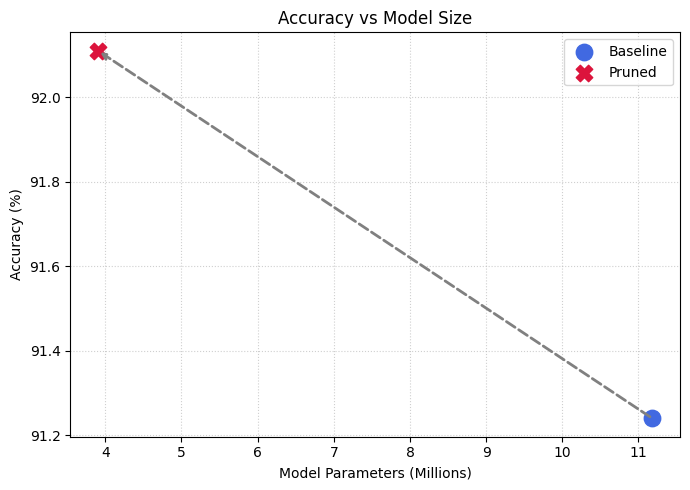

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(baseline_params_val, baseline_acc_val, color='royalblue', s=140, label='Baseline', marker='o', zorder=3)
plt.scatter(pruned_params_val,   pruned_acc_val,   color='crimson',   s=140, label='Pruned',   marker='X', zorder=3)
plt.annotate('', xy=(pruned_params_val, pruned_acc_val),
             xytext=(baseline_params_val, baseline_acc_val),
             arrowprops=dict(arrowstyle='->', lw=2, color='gray', linestyle='--'))
plt.xlabel('Model Parameters (Millions)')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Model Size')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### FLOPs vs Latency

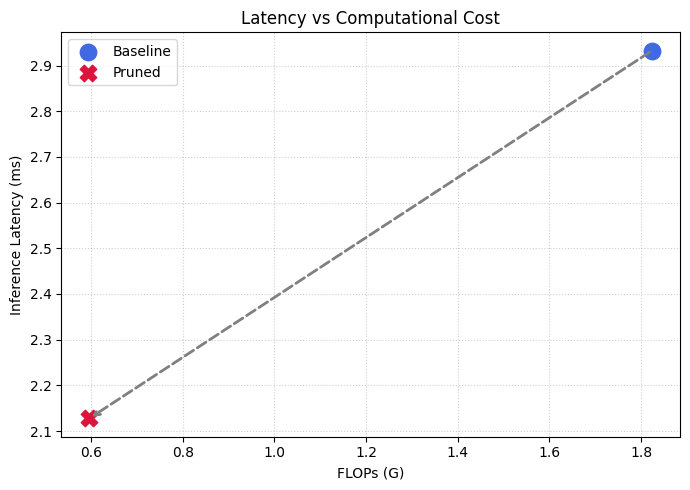

In [12]:
plt.figure(figsize=(7,5))
plt.scatter(baseline_flops_val, baseline_lat_val, color='royalblue', s=140, label='Baseline', marker='o', zorder=3)
plt.scatter(pruned_flops_val,   pruned_lat_val,   color='crimson',   s=140, label='Pruned',   marker='X', zorder=3)
plt.annotate('', xy=(pruned_flops_val, pruned_lat_val),
             xytext=(baseline_flops_val, baseline_lat_val),
             arrowprops=dict(arrowstyle='->', lw=2, color='gray', linestyle='--'))
plt.xlabel('FLOPs (G)')
plt.ylabel('Inference Latency (ms)')
plt.title('Latency vs Computational Cost')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Accuracy vs FLOPs

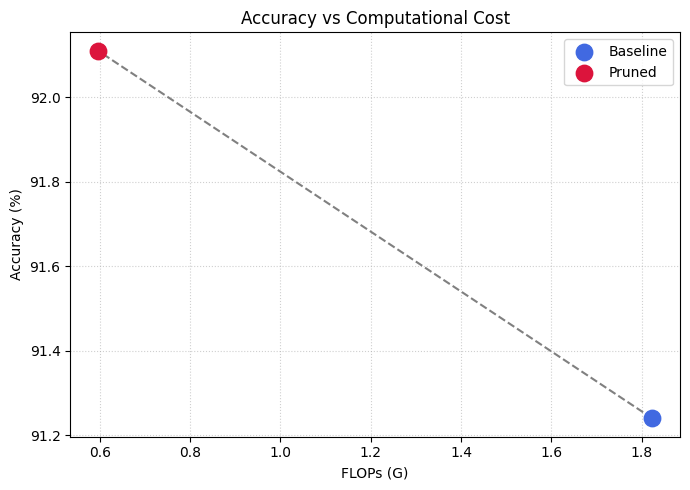

In [13]:
plt.figure(figsize=(7,5))
plt.scatter(baseline_flops_val, baseline_acc_val, color='royalblue', s=140, label='Baseline', zorder=3)
plt.scatter(pruned_flops_val,   pruned_acc_val,   color='crimson',   s=140, label='Pruned',   zorder=3)
plt.plot([baseline_flops_val, pruned_flops_val], [baseline_acc_val, pruned_acc_val],
         linestyle='--', color='gray')
plt.xlabel('FLOPs (G)')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Computational Cost')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### Compression Comparison Bar Chart

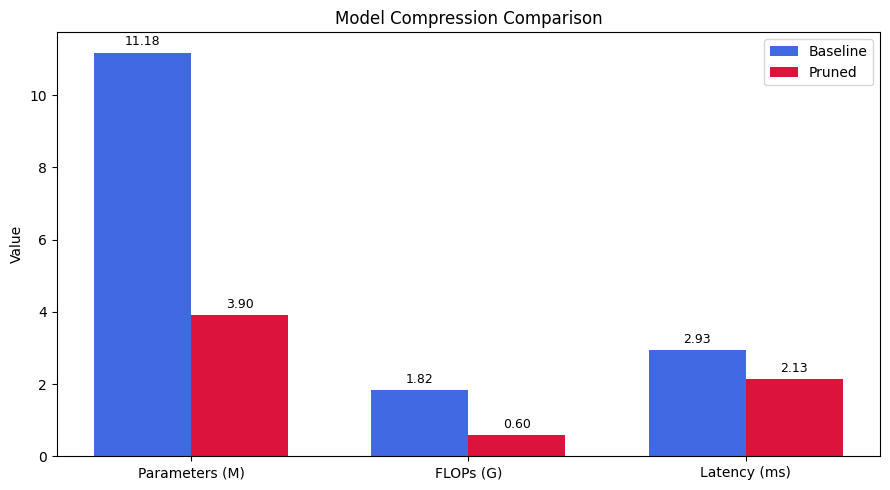

In [14]:
metrics_labels = ['Parameters (M)', 'FLOPs (G)', 'Latency (ms)']
baseline_vals  = [baseline_params_val, baseline_flops_val, baseline_lat_val]
pruned_vals    = [pruned_params_val,   pruned_flops_val,   pruned_lat_val]

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline', color='royalblue')
bars2 = ax.bar(x + width/2, pruned_vals,   width, label='Pruned',   color='crimson')

ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylabel('Value')
ax.set_title('Model Compression Comparison')
ax.legend()
plt.tight_layout()
plt.show()

### Combined Research Figure

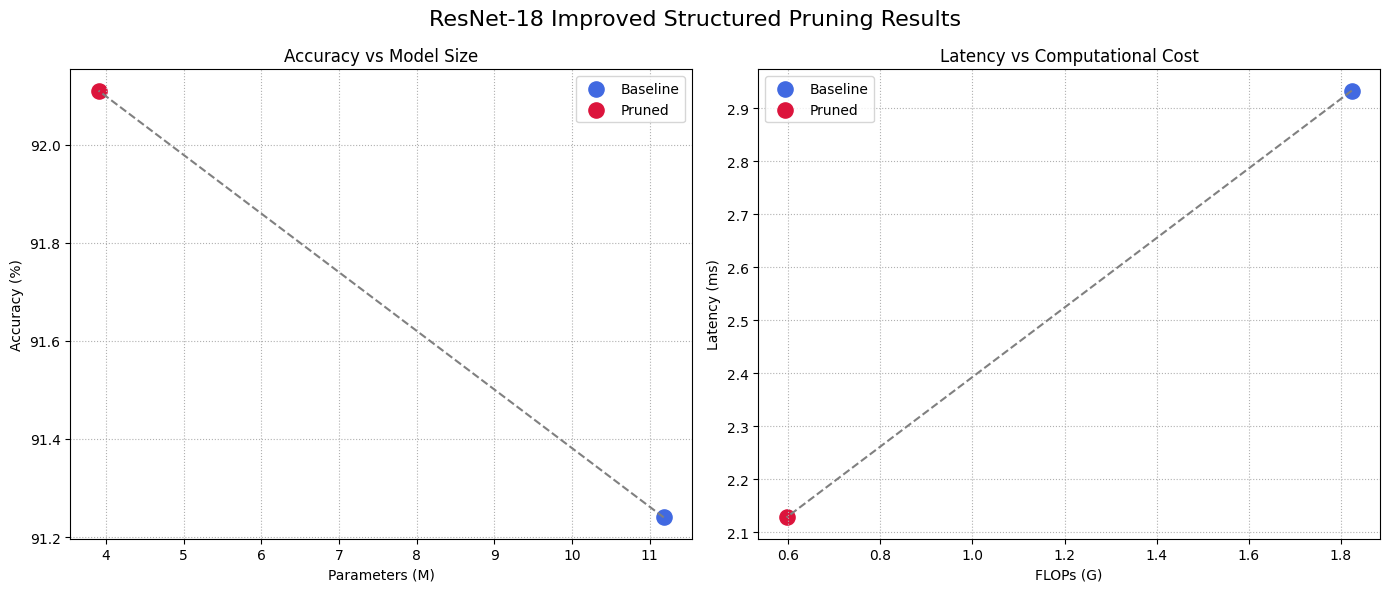

Figure saved to outputs/pruning_results.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
ax1.scatter(baseline_params_val, baseline_acc_val, color='royalblue', s=120, label='Baseline')
ax1.scatter(pruned_params_val,   pruned_acc_val,   color='crimson',   s=120, label='Pruned')
ax1.plot([baseline_params_val, pruned_params_val], [baseline_acc_val, pruned_acc_val], '--', color='gray')
ax1.set_xlabel('Parameters (M)')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy vs Model Size')
ax1.grid(True, linestyle=':')
ax1.legend()

ax2 = axes[1]
ax2.scatter(baseline_flops_val, baseline_lat_val, color='royalblue', s=120, label='Baseline')
ax2.scatter(pruned_flops_val,   pruned_lat_val,   color='crimson',   s=120, label='Pruned')
ax2.plot([baseline_flops_val, pruned_flops_val], [baseline_lat_val, pruned_lat_val], '--', color='gray')
ax2.set_xlabel('FLOPs (G)')
ax2.set_ylabel('Latency (ms)')
ax2.set_title('Latency vs Computational Cost')
ax2.grid(True, linestyle=':')
ax2.legend()

fig.suptitle('ResNet-18 Improved Structured Pruning Results', fontsize=16)
plt.tight_layout()
plt.show()

os.makedirs('outputs', exist_ok=True)
fig.savefig('outputs/pruning_results.png', dpi=300, bbox_inches='tight')
print('Figure saved to outputs/pruning_results.png')

### Cell 15: Export

In [18]:
print('=== EXPORTING ===')
os.makedirs('outputs', exist_ok=True)

# Save full pruned FP32 model
torch.save(model, 'outputs/improved_pruned_resnet18.pth')

# ── TorchScript export ──
model_cpu = model.cpu()
model_cpu.eval()
try:
    scripted = torch.jit.script(model_cpu)
    scripted.save('outputs/scripted_improved_pruned_resnet18.pt')
    print('TorchScript export: SUCCESS')
except Exception as e:
    print(f'Script failed ({e}), falling back to torch.jit.trace')
    traced = torch.jit.trace(model_cpu, torch.randn(1, 3, 224, 224))
    traced.save('outputs/traced_improved_pruned_resnet18.pt')
    print('TorchScript trace export: SUCCESS')

model = model.to(device)  # restore to GPU
print('All outputs saved to outputs/ directory.')

=== EXPORTING ===
TorchScript export: SUCCESS
All outputs saved to outputs/ directory.


### Final Evaluation Summary

In [19]:
model = model.to(device)
final_test_acc = evaluate(model, testloader)

print('\n--- Final Evaluation ---')
print(f'Pruned Model Test Accuracy : {final_test_acc:.2f}%')
print(f'Baseline Model Test Accuracy: {baseline_acc:.2f}%')
print(f'Net Change                 : {final_test_acc - baseline_acc:+.2f}%')
print(f'Parameter Reduction        : {(1 - pruned_params/baseline_params)*100:.1f}%')
print(f'FLOPs Reduction            : {(1 - pruned_flops/baseline_flops)*100:.1f}%')
print(f'Latency Reduction          : {(1 - pruned_latency/baseline_latency)*100:.1f}%')


--- Final Evaluation ---
Pruned Model Test Accuracy : 92.11%
Baseline Model Test Accuracy: 91.24%
Net Change                 : +0.87%
Parameter Reduction        : 65.1%
FLOPs Reduction            : 67.3%
Latency Reduction          : 27.4%
